In [19]:
from whakaari.utils import load_dataframe
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import numpy as np

In [20]:
# df = load_dataframe(r"D:\Project\whakaari\output\predictions\fm_2.00_0.75_2.00_dsar-hf-mf-rsam_hires\consensus.pkl")

# df = load_dataframe(r"D:\Project\whakaari\output_train_1_and_2_DT\predictions\fm_2.00_0.75_2.00_dsar-hf-mf-rsam_hires\consensus.pkl")

df = load_dataframe(r"D:\Project\whakaari\output\predictions\fm_2.00_0.75_2.00_dsar-hf-mf-rsam_hires\consensus.pkl")

In [21]:
df

,consensus
time,
2025-05-13 00:00:00,0.076
2025-05-13 00:10:00,0.082
2025-05-13 00:20:00,0.074
2025-05-13 00:30:00,0.118
2025-05-13 00:40:00,0.106
...,...
2025-06-18 23:10:00,0.210
2025-06-18 23:20:00,0.184
2025-06-18 23:30:00,0.166


In [22]:
df_more_than_threshold = df[df["consensus"] > 0.7]

In [23]:
times = df_more_than_threshold.index

In [24]:
times[0] + timedelta(days=1)

Timestamp('2025-05-18 05:40:00')

In [25]:
def compute_confidence_interval(values: np.ndarray):
    # 500 is number of classifiers
    confidence_interval = 1.96 * (np.sqrt(values * (1 - values) / 500))
    return confidence_interval

In [26]:
ci = compute_confidence_interval(df["consensus"])

In [27]:
new_df = df.resample("1h").mean()

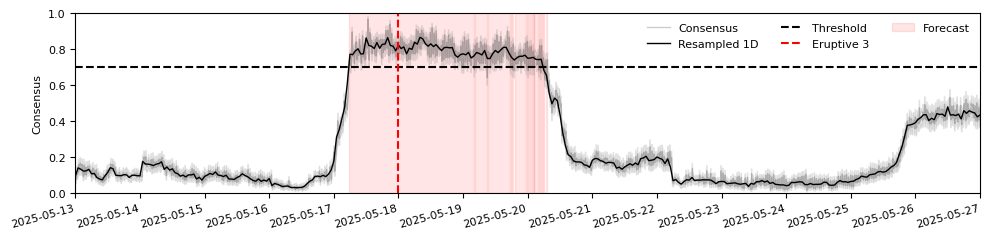

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 2.5))

ax.plot(df.index, df["consensus"], color='black', linewidth=1, label='Consensus', alpha=0.2)
ax.plot(new_df.index, new_df["consensus"], color='k', linewidth=1, label='Resampled 1D')

ax.fill_between(df.index, (df["consensus"] - ci), (df["consensus"] + ci), color="gray", alpha=0.2)
ax.fill_between(df.index, 0, 1.0, where=(df["consensus"] > 0.7), color='red', alpha=0.1, label='Forecast', zorder=-3)

ax.set_ylim(0, 1.0)
# ax.set_xlim(df.index[0], df.index[-1])
ax.set_xlim(datetime.strptime("2025-05-13", "%Y-%m-%d"), datetime.strptime("2025-05-27", "%Y-%m-%d") )

ax.axhline(y=0.7, color='k', linestyle='--', linewidth=1.5, label='Threshold')
ax.set_ylabel('Consensus', fontsize=8)
ax.tick_params(labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

ax.axvline(datetime.strptime("2025-05-18", '%Y-%m-%d'), color='red', linestyle='--', label="Eruptive 3")
# ax.axvline(datetime.strptime("2025-06-17", '%Y-%m-%d'), color='red', linestyle='--', label="Eruptive 4")
# ax.legend(loc='upper center', ncol=6, fontsize=6, frameon=False)
ax.legend(loc='upper right', ncol=3, fontsize=8, frameon=False)

for label in ax.get_xticklabels(which="major"):
    label.set(rotation=15, horizontalalignment="right")

plt.tight_layout()
plt.savefig("OJN_DT_forecast_2025-05-13_2025-05-27_new_", dpi=300)